In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Healthcare Appointment Analytics Dataset.csv to Healthcare Appointment Analytics Dataset.csv


In [5]:
df = pd.read_csv('/content/Healthcare Appointment Analytics Dataset.csv')

In [6]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [7]:
df.shape

(110527, 14)

In [8]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [10]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [11]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.rename(columns={
    'Hipertension':'Hypertension',
    'Handcap':'Handicap',
    'No-show':'No_Show'
}, inplace=True)

In [14]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [15]:
df = df[df['Age'] >= 0]

In [16]:
df['Waiting_Days'] = (
    df['AppointmentDay']
    - df['ScheduledDay']
).dt.days

In [17]:
df = df[df['Waiting_Days'] >= 0]

In [18]:
df['Appointment_Month'] = (
    df['AppointmentDay']
    .dt.month_name()
)

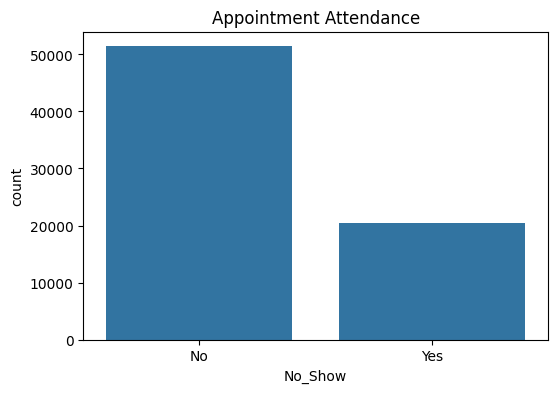

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='No_Show',
    data=df
)
plt.title('Appointment Attendance')
plt.show()

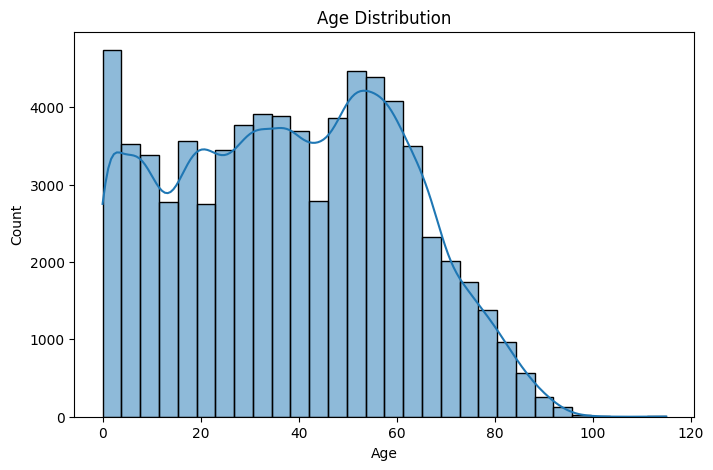

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)
plt.title('Age Distribution')
plt.show()

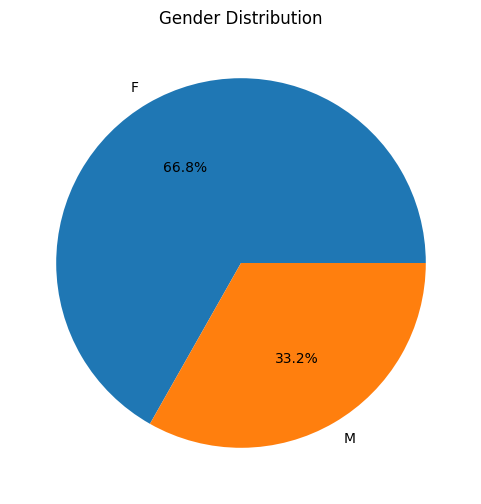

In [21]:
gender = df['Gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    gender,
    labels=gender.index,
    autopct='%1.1f%%'
)
plt.title('Gender Distribution')
plt.show()

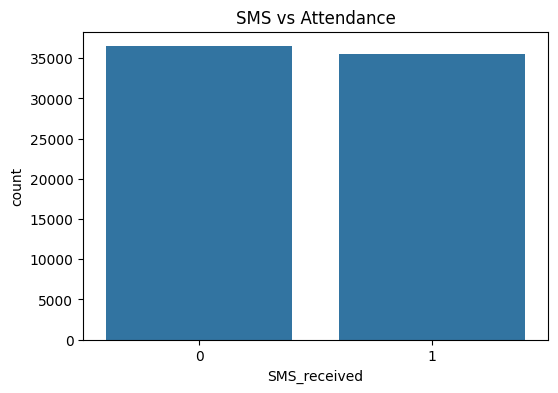

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='SMS_received',
    data=df
)
plt.title('SMS vs Attendance')
plt.show()

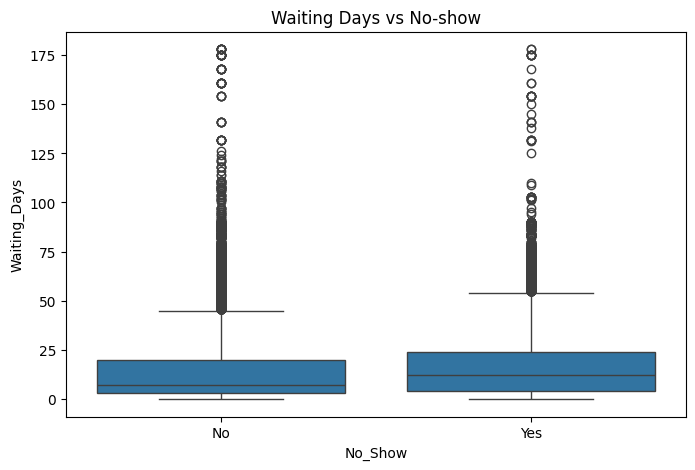

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='No_Show',
    y='Waiting_Days',
    data=df
)

plt.title('Waiting Days vs No-show')

plt.show()

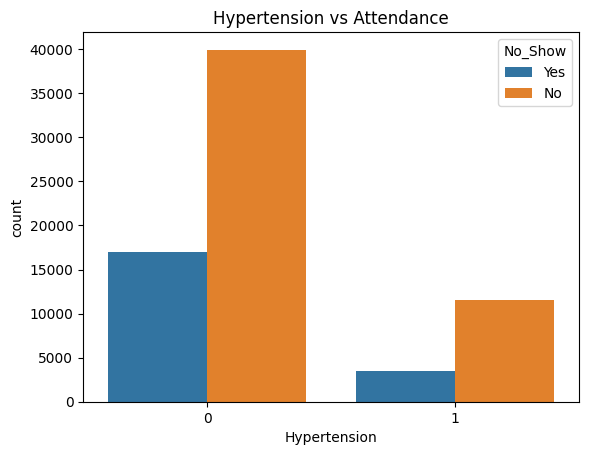

In [24]:
sns.countplot(
    x='Hypertension',
    hue='No_Show',
    data=df
)

plt.title('Hypertension vs Attendance')

plt.show()

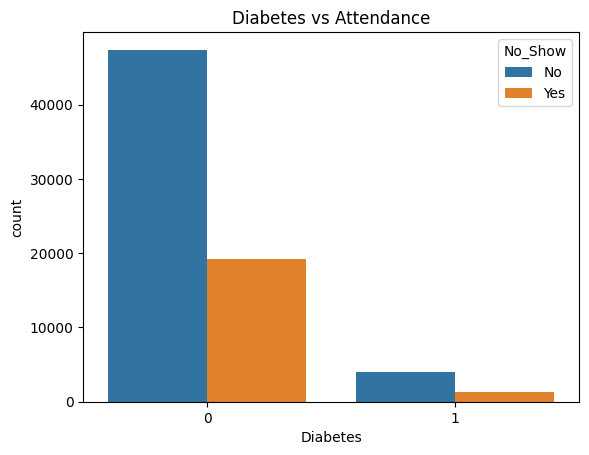

In [25]:
sns.countplot(
    x='Diabetes',
    hue='No_Show',
    data=df
)

plt.title('Diabetes vs Attendance')

plt.show()

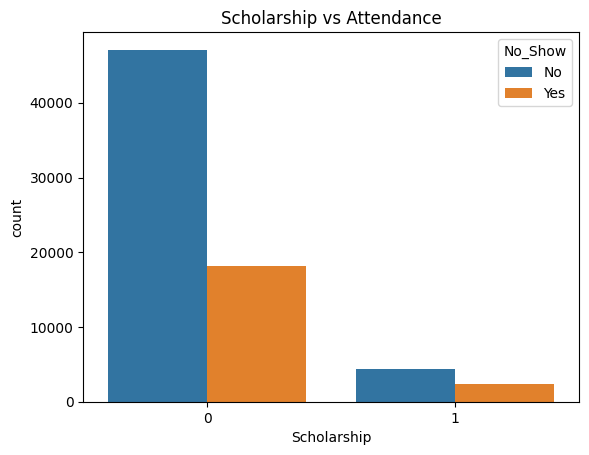

In [26]:
sns.countplot(
    x='Scholarship',
    hue='No_Show',
    data=df
)

plt.title('Scholarship vs Attendance')

plt.show()

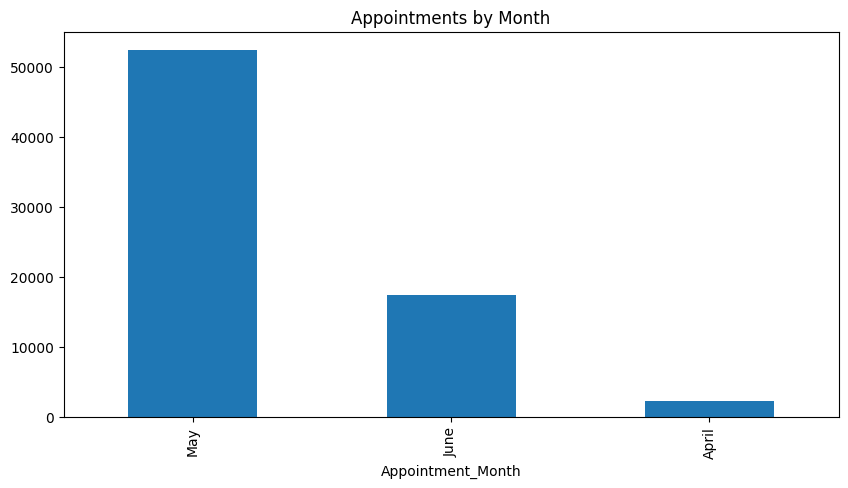

In [27]:
monthly = df['Appointment_Month'].value_counts()
plt.figure(figsize=(10,5))
monthly.plot(kind='bar')
plt.title('Appointments by Month')
plt.show()

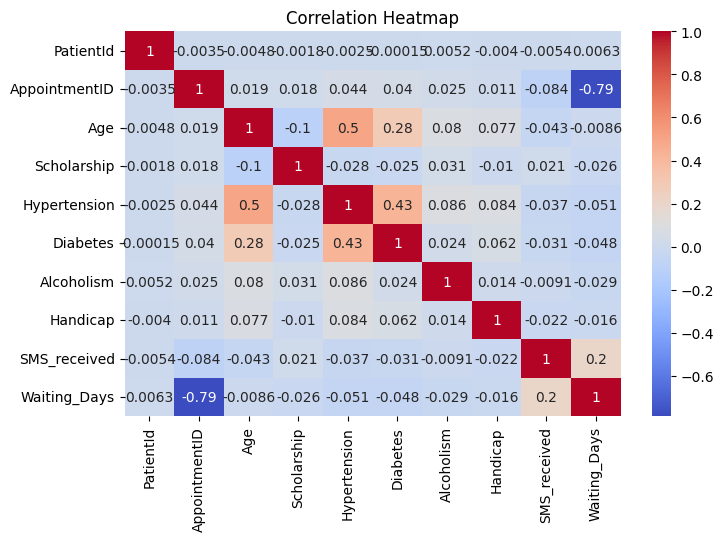

In [28]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [29]:
df.to_csv(
    'healthcare_cleaned.csv',
    index=False
)

In [30]:
from google.colab import files

files.download(
    'healthcare_cleaned.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>